# Morphological Operations

This notebook demonstrates dilation, erosion, opening, and closing on a binary image derived from `selfie.jpg`.
To make the effects more visible, a small amount of synthetic salt-and-pepper noise is added before the morphological operations are applied.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def load_image_unicode(image_path, flags=cv2.IMREAD_COLOR):
    image_bytes = np.fromfile(str(image_path), dtype=np.uint8)
    image = cv2.imdecode(image_bytes, flags)
    if image is None:
        raise ValueError(f'Failed to load image: {image_path}')
    return image


rng = np.random.default_rng(7)
image_path = Path('selfie.jpg')
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

image_bgr = load_image_unicode(image_path)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

_, binary_mask = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

noise = rng.random(binary_mask.shape)
noisy_mask = binary_mask.copy()
noisy_mask[noise < 0.01] = 255
noisy_mask[noise > 0.99] = 0

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

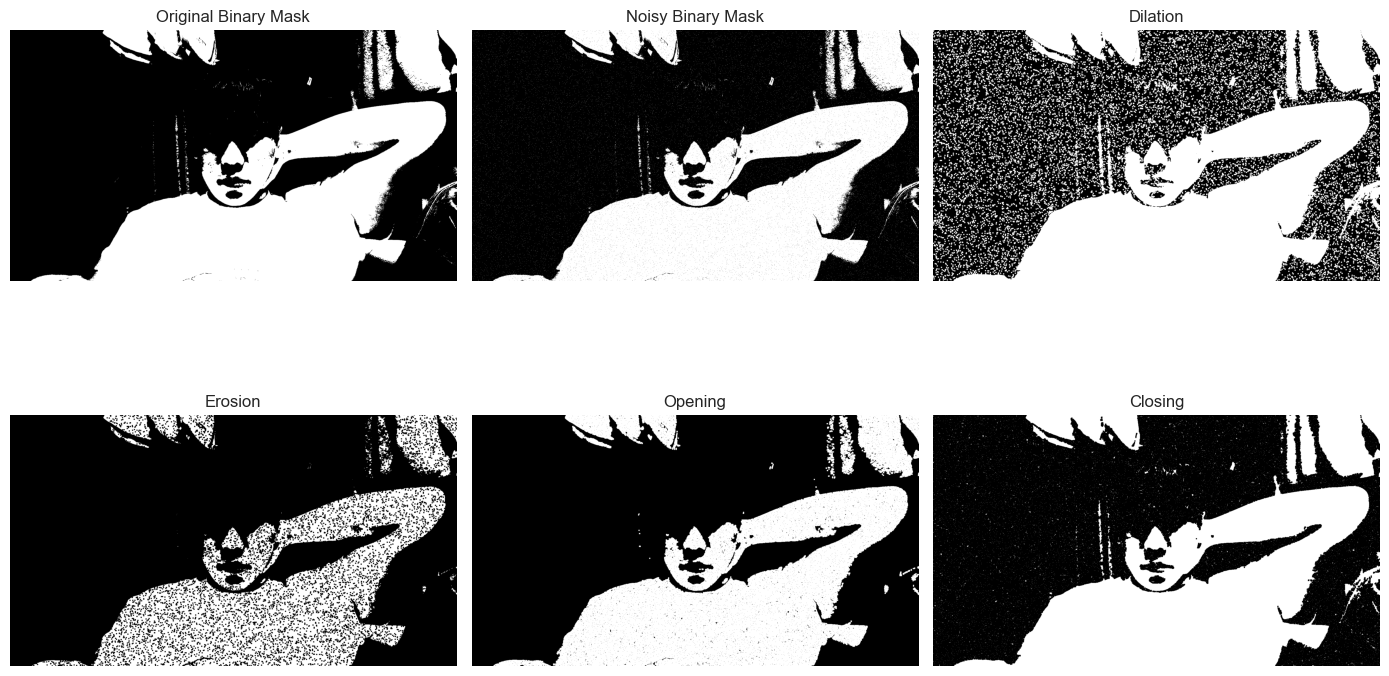

In [3]:
dilation = cv2.dilate(noisy_mask, kernel, iterations=1)
erosion = cv2.erode(noisy_mask, kernel, iterations=1)
opening = cv2.morphologyEx(noisy_mask, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(noisy_mask, cv2.MORPH_CLOSE, kernel)

images = {
    'Original Binary Mask': binary_mask,
    'Noisy Binary Mask': noisy_mask,
    'Dilation': dilation,
    'Erosion': erosion,
    'Opening': opening,
    'Closing': closing,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (title, img) in zip(axes.ravel(), images.items()):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

fig.savefig(results_dir / '4_morphological_operations.png', dpi=180, bbox_inches='tight')

In [4]:
def white_ratio(image):
    return np.count_nonzero(image == 255) / image.size


for name, image in images.items():
    print(f"{name:<22} white-pixel ratio = {white_ratio(image):.4f}")

Original Binary Mask   white-pixel ratio = 0.3638
Noisy Binary Mask      white-pixel ratio = 0.3665
Dilation               white-pixel ratio = 0.5308
Erosion                white-pixel ratio = 0.2589
Opening                white-pixel ratio = 0.3471
Closing                white-pixel ratio = 0.3839
